# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych

In [2]:
steps = {
    0:  100,
    1:   99,
    2:   98,
    3:   96,
    4:   95,
    5:   94,
    6:   92,
    7:   90,
    8:   89,
    9:   87,
    10:  85,
    11:  83,
    12:  81,
    13:  79,
    14:  76,
    15:  74,
    16:  71,
    17:  68,
    18:  65,
    19:  61,
    20:  58,
    21:  54,
    22:  49,
    23:  44,
    24:  39,
    25:  33,
    26:  26,
    27:  19,
    28:  10,
    29:   1,
}

In [3]:
lam = 2
n_replicas = 2
n_samples = 1

swap_algorithm = {
	"p_ratio" : "p",
	"odd":   [ steps[0], steps[2], steps[4], steps[6], steps[8], steps[10], steps[12], steps[16], steps[20]],
	"even":  [ steps[1], steps[3], steps[5], steps[7], steps[9], steps[11], steps[14], steps[18], steps[22]],
	"debug" : True
}

# Composed Dataset

 diff 1.0000022649765015


/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/toy/src/score_integral.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


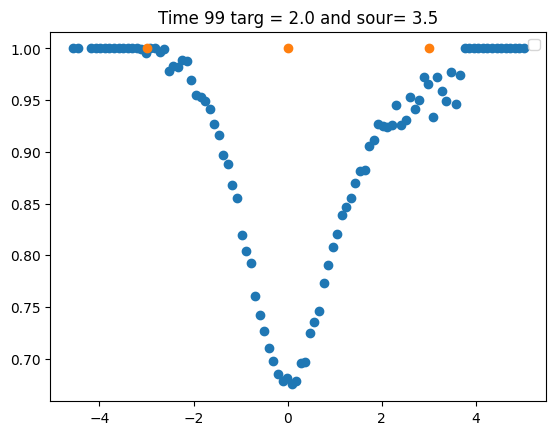

p ratio.         0.7947636246681213 std 0.29549574851989746
Time 99 swap btwn source 3.50 and target 2.00 accept 0.79 
 diff 1.0054537057876587


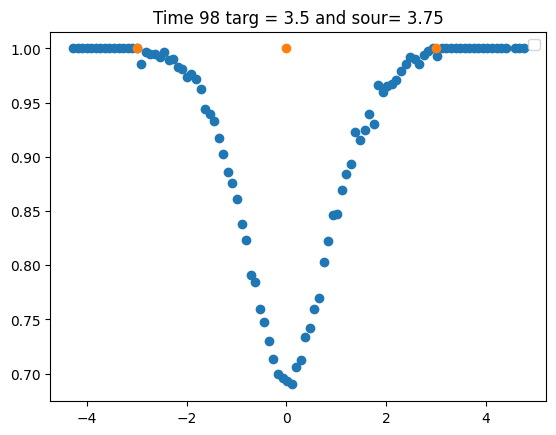

p ratio.         0.8177806735038757 std 0.27540114521980286
Time 98 swap btwn source 3.75 and target 3.50 accept 0.82 
 diff 1.019321084022522


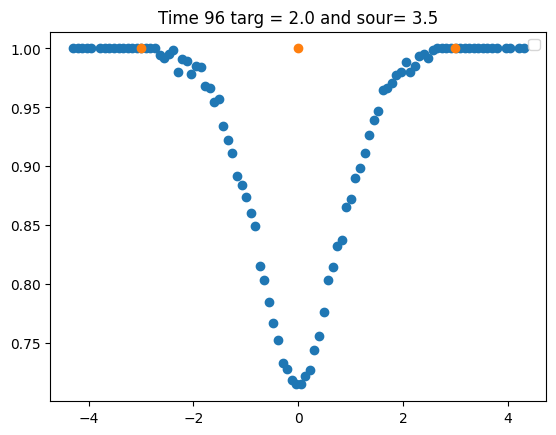

p ratio.         0.825439989566803 std 0.2629649043083191
Time 96 swap btwn source 3.50 and target 2.00 accept 0.83 
 diff 1.0846929550170898


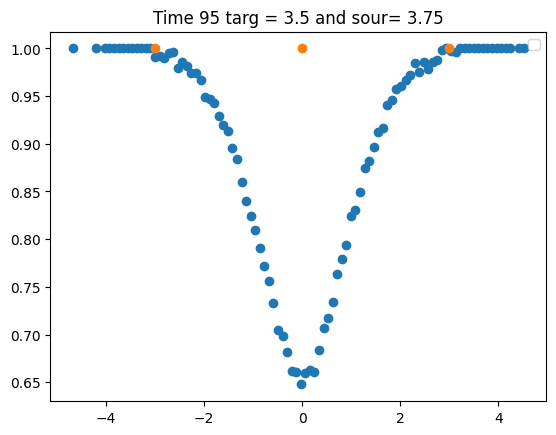

p ratio.         0.7931240200996399 std 0.3001853823661804
Time 95 swap btwn source 3.75 and target 3.50 accept 0.79 
 diff 1.0520151853561401


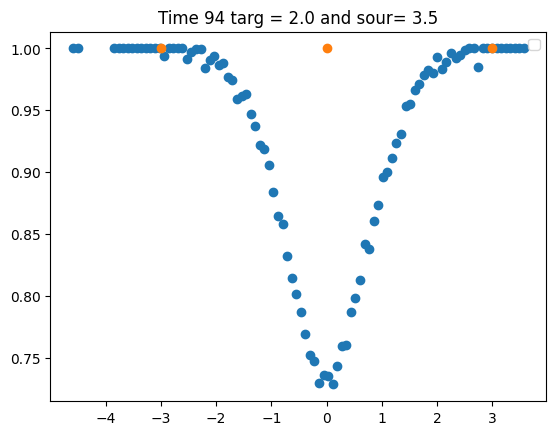

p ratio.         0.8321650624275208 std 0.2521471679210663
Time 94 swap btwn source 3.50 and target 2.00 accept 0.83 
 diff 1.2436093091964722


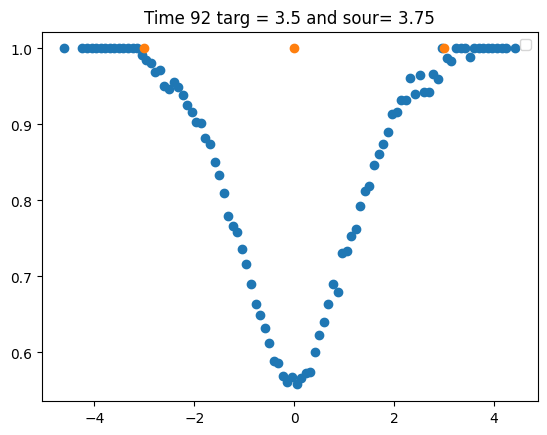

p ratio.         0.7058429718017578 std 0.35536232590675354
Time 92 swap btwn source 3.75 and target 3.50 accept 0.71 
 diff 1.1521151065826416


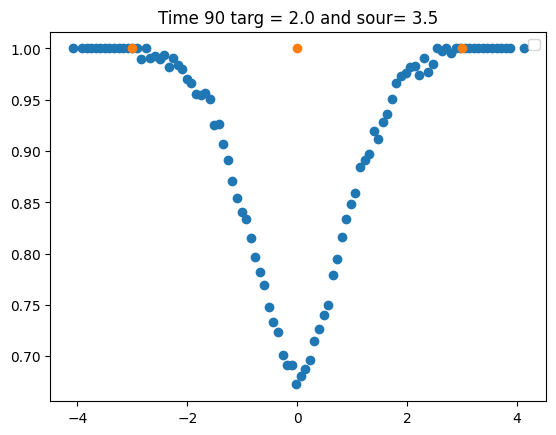

p ratio.         0.7983646392822266 std 0.2855377495288849
Time 90 swap btwn source 3.50 and target 2.00 accept 0.80 
 diff 1.4544717073440552


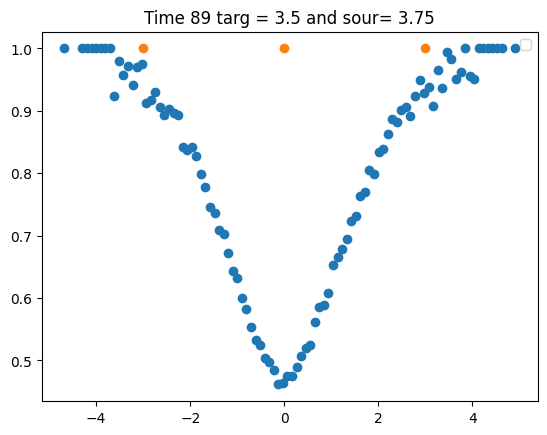

p ratio.         0.6363576650619507 std 0.3933357894420624
Time 89 swap btwn source 3.75 and target 3.50 accept 0.64 
 diff 1.2437169551849365


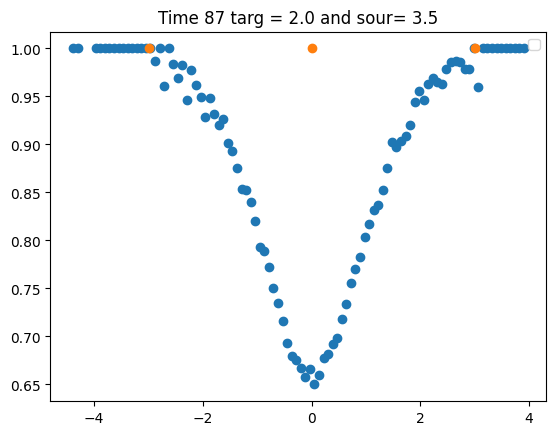

p ratio.         0.7626405358314514 std 0.3074749708175659
Time 87 swap btwn source 3.50 and target 2.00 accept 0.76 
 diff 1.7667882442474365


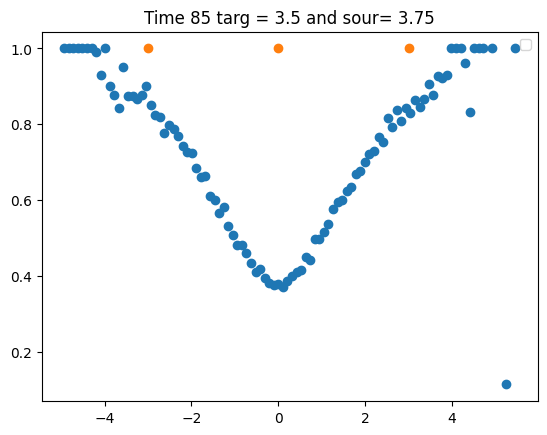

p ratio.         0.539215624332428 std 0.42248567938804626
Time 85 swap btwn source 3.75 and target 3.50 accept 0.54 
 diff 1.3685394525527954


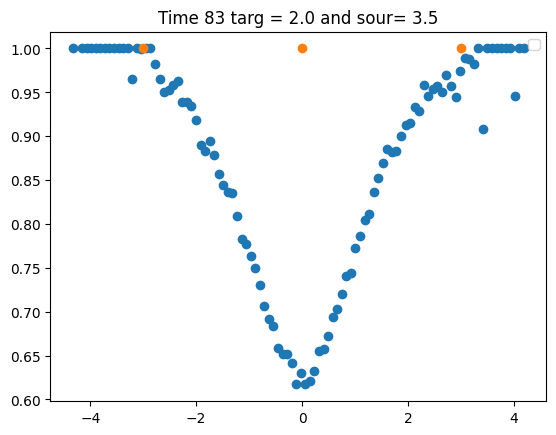

p ratio.         0.7372366786003113 std 0.32689082622528076
Time 83 swap btwn source 3.50 and target 2.00 accept 0.74 
 diff 2.069068670272827


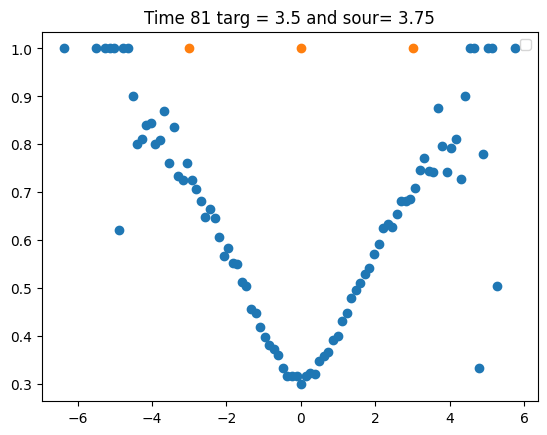

p ratio.         0.4600624144077301 std 0.4320177733898163
Time 81 swap btwn source 3.75 and target 3.50 accept 0.46 
 diff 1.5581318140029907


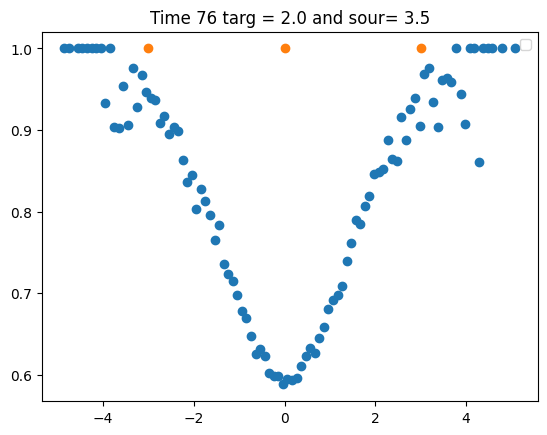

p ratio.         0.6945447325706482 std 0.359579473733902
Time 76 swap btwn source 3.50 and target 2.00 accept 0.69 
 diff 2.6546497344970703


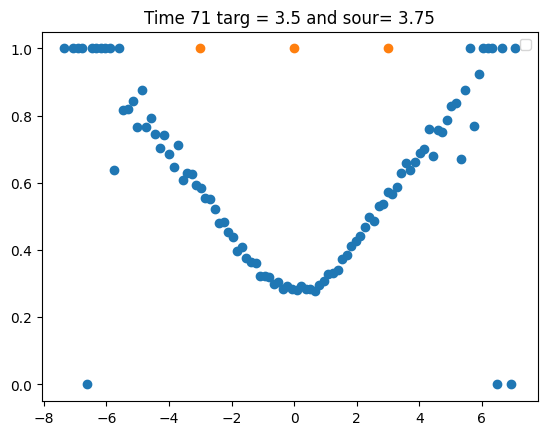

p ratio.         0.4120253026485443 std 0.4449925720691681
Time 71 swap btwn source 3.75 and target 3.50 accept 0.41 
 diff 1.7553787231445312


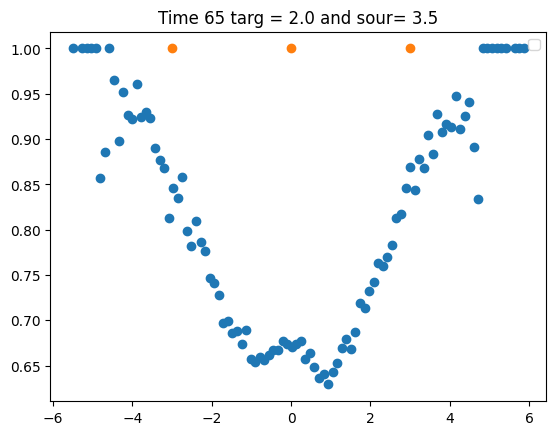

p ratio.         0.6990943551063538 std 0.3783967196941376
Time 65 swap btwn source 3.50 and target 2.00 accept 0.70 
 diff 3.0810818672180176


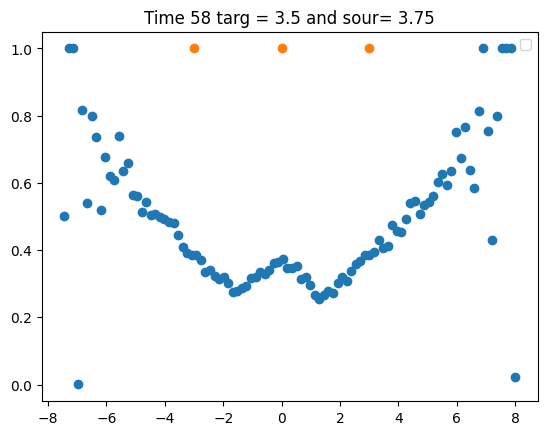

p ratio.         0.35627982020378113 std 0.44123080372810364
Time 58 swap btwn source 3.75 and target 3.50 accept 0.36 
 diff 1.897761583328247


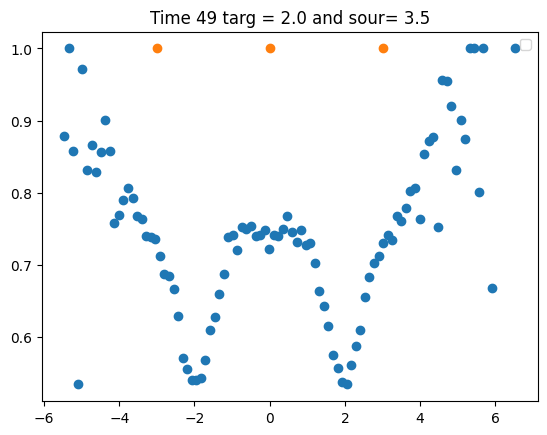

p ratio.         0.6787135601043701 std 0.3887559473514557
Time 49 swap btwn source 3.50 and target 2.00 accept 0.68 


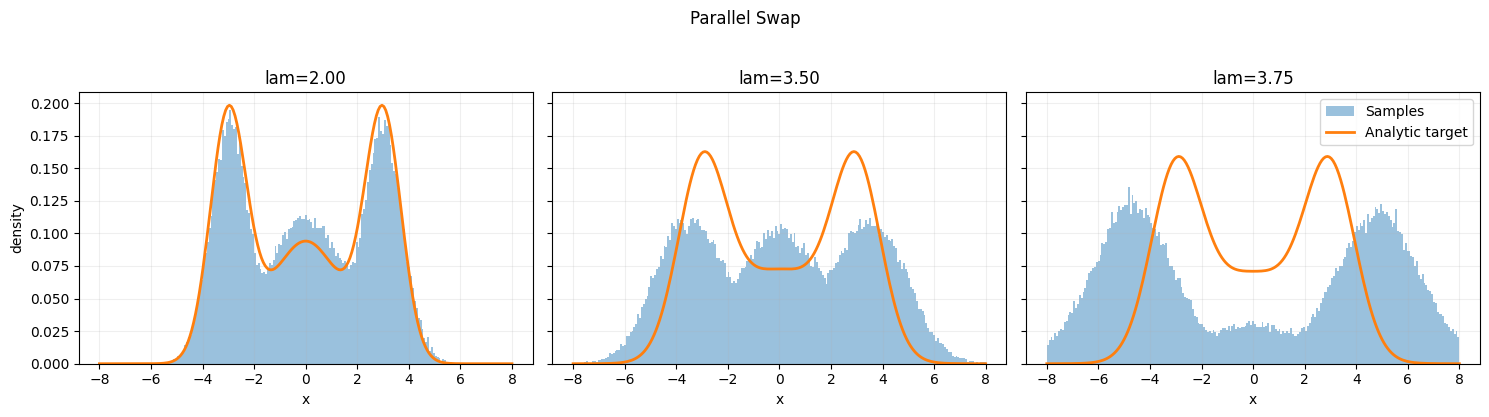

In [4]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=True,
	swap_algorithm=swap_algorithm,
)

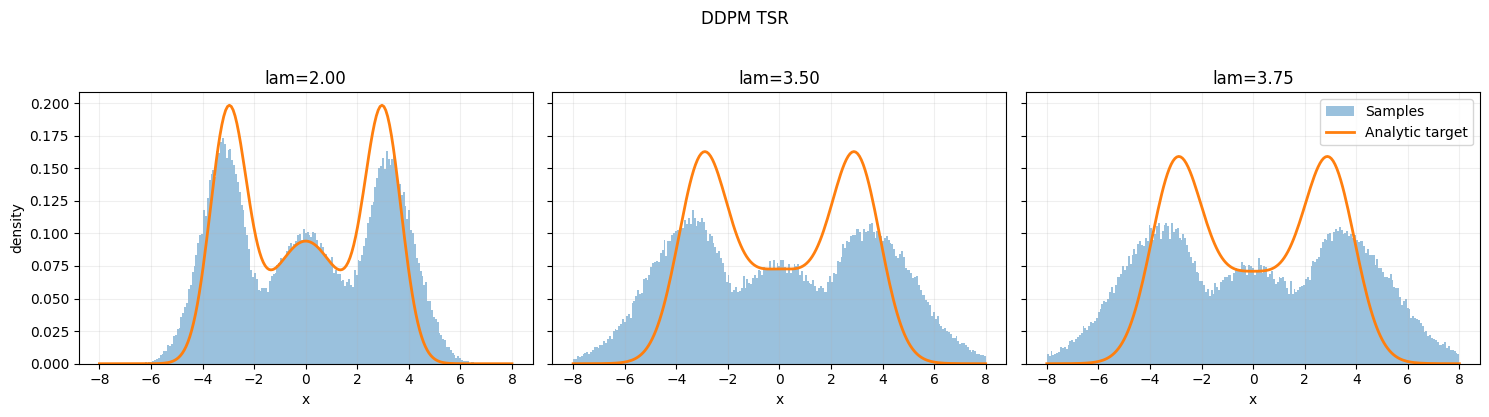

In [5]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=False,
	swap_algorithm=swap_algorithm
)

# MNIST Dataset

In [6]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=0.5,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

In [7]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=2.0,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

# Best of N

In [8]:
# _ = plot_temperature_triptych(
# 	dataset_name="composed",
# 	k=k,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=True,
# 	swap_algorithm=swap_algorithm,
# 	best_of_n_runs=4
# )